# Workshop 10

In [11]:
import nltk, re, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from nltk.corpus import movie_reviews, stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import *
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
nltk.download('movie_reviews'); nltk.download('stopwords'); nltk.download('punkt');nltk.download('punkt_tab')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### EX 1 - Sentiment Analysis (Section 2 in PDF)

In [12]:

docs = [
    (" ".join(movie_reviews.words(f)), c)
    for c in movie_reviews.categories()
    for f in movie_reviews.fileids(c)
]

df = pd.DataFrame(docs, columns=['r', 's'])

st = PorterStemmer()
sw = set(stopwords.words('english'))

def proc(t):
    t = re.sub(r'[^a-zA-Z\s]', '', t.lower())
    return " ".join(st.stem(w) for w in word_tokenize(t) if w not in sw)

df['pr'] = df['r'].apply(proc)


In [13]:
xt, xv, yt, yv = train_test_split(df['pr'], df['s'], test_size=0.2, random_state=42)
cv = CountVectorizer()
xt_b, xv_b = cv.fit_transform(xt), cv.transform(xv)
nb = MultinomialNB().fit(xt_b, yt)

Acc: 0.8025
              precision    recall  f1-score   support

         neg       0.79      0.83      0.81       199
         pos       0.82      0.78      0.80       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



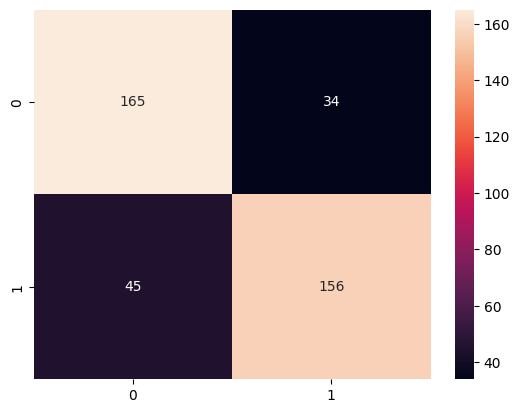

In [14]:
yp = nb.predict(xv_b)
yprob = nb.predict_proba(xv_b)[:, 1]
print(f"Acc: {accuracy_score(yv, yp):.4f}")
print(classification_report(yv, yp))
sns.heatmap(confusion_matrix(yv, yp), annot=True, fmt='d'); plt.show()

### EX 3 - Feature Selection (Section 3 in PDF)

In [15]:
bc = fetch_openml(data_id=35, as_frame=True).frame.dropna()
X, y = bc.iloc[:, :-1], LabelEncoder().fit_transform(bc.iloc[:, -1])
Xs = StandardScaler().fit_transform(X)
xt2, xv2, yt2, yv2 = train_test_split(Xs, y, test_size=0.2, random_state=42)

top 5: ['koebner_phenomenon', 'fibrosis_of_the_papillary_dermis', 'elongation_of_the_rete_ridges', 'vacuolisation_and_damage_of_basal_layer', 'spongiosis']


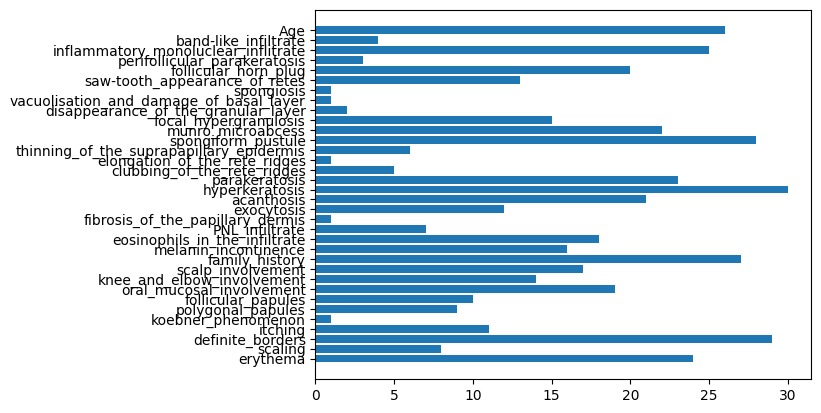

In [16]:
lr = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=lr, n_features_to_select=5).fit(xt2, yt2)
print(f"top 5: {X.columns[rfe.support_].tolist()}")
plt.barh(X.columns, rfe.ranking_); plt.show()

In [17]:
lr = LogisticRegression(max_iter=1000)

def eval(xtr, xte, ytr, yte, l):
    m = LogisticRegression(max_iter=1000)
    m.fit(xtr, ytr)
    p = m.predict(xte)
    return {
        'l': l,
        'acc': accuracy_score(yte, p),
        'f1': f1_score(yte, p, average='macro')
    }

res = [eval(xt2, xv2, yt2, yv2, "all")]

for n in [5, 3, 7]:
    rf = RFE(estimator=lr, n_features_to_select=n)
    rf.fit(xt2, yt2)
    res.append(
        eval(
            rf.transform(xt2),
            rf.transform(xv2),
            yt2,
            yv2,
            f"top {n}"
        )
    )

print(pd.DataFrame(res))


       l       acc        f1
0    all  0.958333  0.954691
1  top 5  0.944444  0.790198
2  top 3  0.833333  0.600284
3  top 7  0.986111  0.984023


### Discussion: Filtering out junk data with feature selection helps the model stay focused and efficient.